## Definitions

In [19]:
import os
import numpy as np
import matplotlib.pyplot as plt

from tensorflow.keras.utils import to_categorical
from keras.callbacks import ReduceLROnPlateau, ModelCheckpoint, EarlyStopping
from tensorflow.keras.optimizers import Adadelta, Adam, SGD
from keras.layers import Input, Conv2D, Dense, MaxPooling2D, Dropout, Flatten, AveragePooling2D, Conv2DTranspose, UpSampling2D, BatchNormalization
from keras.models import Sequential
from keras.losses import categorical_crossentropy

from keras.datasets import mnist

## Load and format data

Number of classes: 10
Example of handwritten digit with correlated noise: 



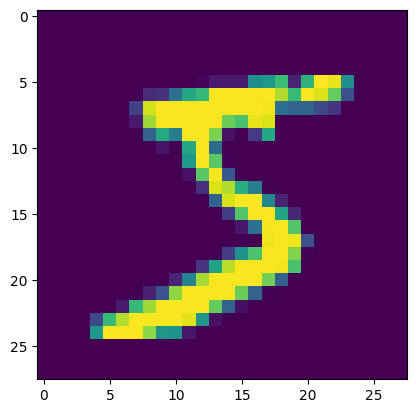

Class: 5

Shape of x_train: (60000, 28, 28, 1)
Shape of y_train: (60000, 10)


In [25]:
(x_train, y_train), (x_test, y_test) = mnist.load_data()

num_cls = len(np.unique(y_train))
print('Number of classes: ' + str(num_cls))

print('Example of handwritten digit with correlated noise: \n')

k = 0
plt.imshow(np.squeeze(x_train[k,:,:]))
plt.show()
print('Class: '+str(y_train[k])+'\n')

# RESHAPE and standarize
x_train = np.expand_dims(x_train/255,axis=3)

# convert class vectors to binary class matrices
y_train = to_categorical(y_train, num_cls)

print('Shape of x_train: '+str(x_train.shape))
print('Shape of y_train: '+str(y_train.shape))

## Training

In [29]:
model_name='CNN_test1' # To compare models, you can give them different names

pweight='./weights/weights_' + model_name  + '.keras'

if not os.path.exists('./weights'):
  os.mkdir('./weights')


## EXPLORE VALUES AND FIND A GOOD SET
b_size = 4 # batch size
val_split = 0.5 # percentage of samples used for validation (e.g. 0.5)
ep = 20 # number of epochs

Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_15 (Conv2D)              │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_12 (MaxPooling2D) │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_16          │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_8 (Flatten)             │ (None, 3136)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 10)             │        31,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 31,594 (123.41 KB)

 Trainable params: 31,562 (123.29 KB)

 Non-trainable params: 32 (128.00 B)

Epoch 1/20
7467/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.8733 - loss: 0.4340
Epoch 1: val_loss improved from inf to 0.17232, saving model to ./weights/weights_CNN_test1.keras
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 13s 2ms/step - accuracy: 0.8735 - loss: 0.4333 - val_accuracy: 0.9496 - val_loss: 0.1723
Epoch 2/20
7469/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9419 - loss: 0.2059
Epoch 2: val_loss did not improve from 0.17232
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9419 - loss: 0.2059 - val_accuracy: 0.9477 - val_loss: 0.1780
Epoch 3/20
7474/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - accuracy: 0.9522 - loss: 0.1677
Epoch 3: val_loss improved from 0.17232 to 0.16213, saving model to ./weights/weights_CNN_test1.keras
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9522 - loss: 0.1678 - val_accuracy: 0.9553 - val_loss: 0.1621
Epoch 4/20
7491/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 986us/step - accuracy: 0.9559 - loss: 0.1586
Epoch 4: val_loss did not improve from 

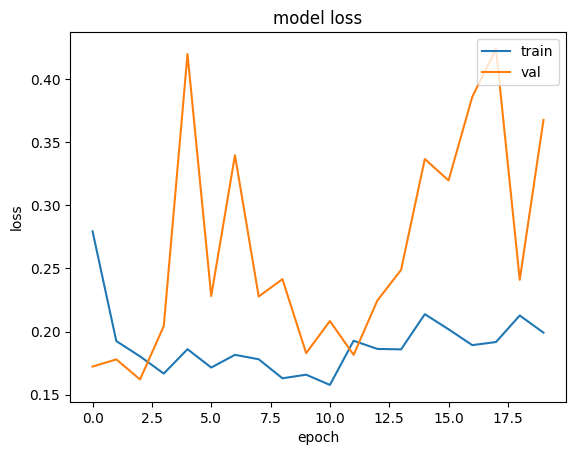

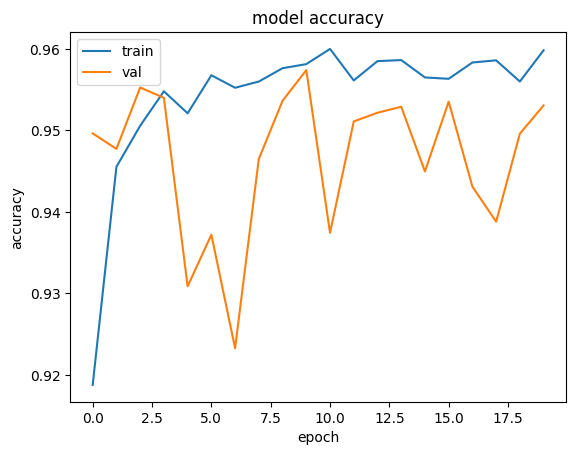

In [ ]:
input_shape = x_train.shape[1:4] #(28,28,1)
model = Sequential()

## EXPLORE LAYERS, # CHANNELS... Conv2D, Dense, MaxPooling2D, Dropout, Flatten, AveragePooling2D, Conv2DTranspose, UpSampling2D
## SEE KERAS MANUAL https://keras.io/layers/about-keras-layers/
model.add(Conv2D(16, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape)) # explore num channels and adding more layers
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

##### 

model.add(Flatten()) # transforms matrix feature map to vector for dense layer (fully connected)

model.add(Dense(num_cls, activation='softmax')) # This is a necessary output layer, however, you can add more dense layers before with different activation functions


model.compile(loss=categorical_crossentropy,
              optimizer=SGD(learning_rate=0.01, momentum=0.9), # explore other optimizers: Adam, SGD, Adadelta
              metrics=['accuracy'])

model.summary()

checkpointer = ModelCheckpoint(filepath=pweight, verbose=1, save_best_only=True)
callbacks_list = [checkpointer] # explore adding other callbacks such as ReduceLROnPlateau, EarlyStopping

history=model.fit(x_train, y_train,
                        epochs=ep,
                        batch_size=b_size,
                        verbose=1,
                        shuffle=True,
                        validation_split = val_split,
                        callbacks=callbacks_list)

print('CNN weights saved in ' + pweight)

# Plot loss vs epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

# Plot accuracy vs epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 14, 14, 16)     │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 14, 14, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 7, 7, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 7, 7, 32)       │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_6 (Conv2D)               │ (None, 7, 7, 64)       │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 4, 4, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 4, 4, 64)       │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_7 (Conv2D)               │ (None, 4, 4, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 2, 2, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 2, 2, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 100)            │        51,300 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 100)            │           400 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │         1,010 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 150,822 (589.15 KB)

 Trainable params: 150,142 (586.49 KB)

 Non-trainable params: 680 (2.66 KB)

Epoch 1/26
7490/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8279 - loss: 0.5629
Epoch 1: val_loss improved from inf to 0.26768, saving model to ./weights/weights_CNN.keras
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 30s 4ms/step - accuracy: 0.8280 - loss: 0.5626 - val_accuracy: 0.9455 - val_loss: 0.2677
Epoch 2/26
7491/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9384 - loss: 0.2256
Epoch 2: val_loss improved from 0.26768 to 0.21268, saving model to ./weights/weights_CNN.keras
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.9384 - loss: 0.2256 - val_accuracy: 0.9652 - val_loss: 0.2127
Epoch 3/26
7497/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9494 - loss: 0.1803
Epoch 3: val_loss improved from 0.21268 to 0.07950, saving model to ./weights/weights_CNN.keras
7500/7500 ━━━━━━━━━━━━━━━━━━━━ 31s 4ms/step - accuracy: 0.9494 - loss: 0.1803 - val_accuracy: 0.9779 - val_loss: 0.0795
Epoch 4/26
7497/7500 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9526 - loss: 0.1710
Epoc

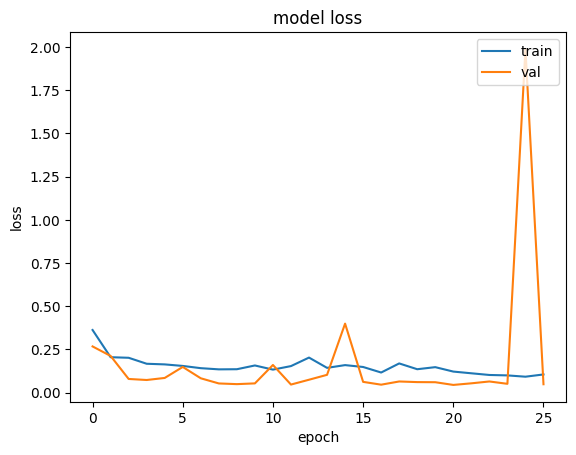

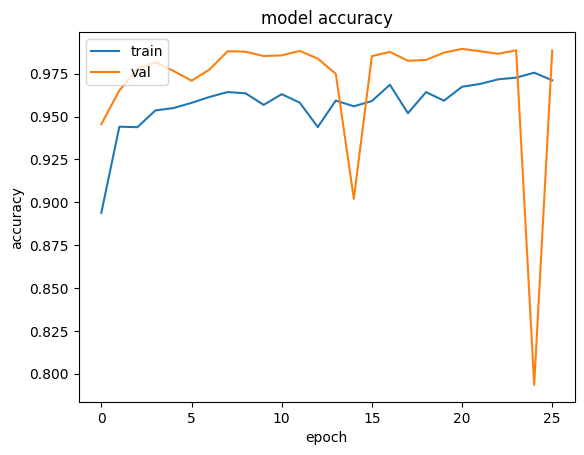

In [8]:
input_shape = x_train.shape[1:4] #(28,28,1)
model = Sequential()

## EXPLORE LAYERS, # CHANNELS... Conv2D, Dense, MaxPooling2D, Dropout, Flatten, AveragePooling2D, Conv2DTranspose, UpSampling2D
## SEE KERAS MANUAL https://keras.io/layers/about-keras-layers/
model.add(Conv2D(16, kernel_size=(3, 3), padding='same', activation='relu', input_shape=input_shape)) # explore num channels and adding more layers
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

model.add(Conv2D(32, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(2,2))
model.add(BatchNormalization())

model.add(Conv2D(64, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(padding='same'))
model.add(BatchNormalization())

model.add(Conv2D(128, kernel_size=(3, 3), padding='same', activation='relu'))
model.add(MaxPooling2D(padding='same'))
model.add(BatchNormalization())

model.add(Flatten()) # transforms matrix feature map to vector for dense layer (fully connected)

model.add(Dense(100, activation='relu'))
model.add(BatchNormalization())
model.add(Dense(num_cls, activation='softmax')) # This is a necessary output layer, however, you can add more dense layers before with different activation functions

model.compile(loss=categorical_crossentropy,
              optimizer=SGD(learning_rate=0.01, momentum=0.9), # explore other optimizers: Adam, SGD, Adadelta
              metrics=['accuracy'])

model.summary()

checkpointer = ModelCheckpoint(filepath=pweight, verbose=1, save_best_only=True)
callbacks_list = [checkpointer] # explore adding other callbacks such as ReduceLROnPlateau, EarlyStopping

history=model.fit(x_train, y_train,
                        epochs=ep,
                        batch_size=b_size,
                        verbose=1,
                        shuffle=True,
                        validation_split = val_split,
                        callbacks=callbacks_list)

print('CNN weights saved in ' + pweight)

# Plot loss vs epochs
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('model loss')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper right')
plt.show()

# Plot accuracy vs epochs
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.title('model accuracy')
plt.ylabel('accuracy')
plt.xlabel('epoch')
plt.legend(['train', 'val'], loc='upper left')
plt.show()

## Make predictions in test set

In [31]:
from keras.models import load_model

num_cls = len(np.unique(y_test))
print('Number of classes: ' + str(num_cls))

# RESHAPE and standarize
x_test = np.expand_dims(x_test/255,axis=3)

print('Shape of x_test: '+str(x_test.shape)+'\n')

## Define model parameters
model_name='CNN' # To compare models, you can give them different names
pweight='./weights/weights_' + model_name  + '.keras'

model = load_model(pweight)
y_pred_aux = model.predict(x_test)
y_pred=np.argmax(y_pred_aux,axis=1)

Acc_pred = sum(y_pred == y_test)/len(y_test)

print('Accuracy in test set is: '+str(Acc_pred))


Number of classes: 10
Shape of x_test: (10000, 28, 28, 1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step
Accuracy in test set is: 0.9737
